# Compare local Clef with Claude judges

Use TruLens `Metric`, `Jury.repeated`, `AlignmentReport`, and `CrossModelAlignmentReport` to compare local Ollama Clef with Claude Opus 5.5 and Sonnet 5.5 through Snowflake Cortex.

The saved results cover 100 held-out SummEval summaries, three calls per judge. Replaying this notebook makes no model calls. Set `RUN_LIVE = True` only to run a new paid comparison.

Two small protocol adapters handle Ollama's System One endpoint and Cortex's Messages endpoint. TruLens handles score parsing, repeated-trial reliability, jury aggregation, and alignment diagnostics.

In [ ]:
import json
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
from trulens.benchmark import AlignmentReport
from trulens.benchmark.cross_model_alignment import CrossModelAlignmentReport
from trulens.core import Metric
from trulens.feedback import Jury

RUN_LIVE = False
N_EXAMPLES = 100
N_TRIALS = 3
THRESHOLD = 0.75

example_dir = Path.cwd()
if example_dir.name != "clef_judge_comparison":
    example_dir /= (
        "examples/expositional/models/local_and_OSS_models/"
        "clef_judge_comparison"
    )
snapshot_path = example_dir / "results_snapshot.json"

## Optional live evaluation

Leave `RUN_LIVE=False` to inspect saved results. Live mode downloads the pinned public SummEval dataset, uses article-disjoint splits, warms local Clef, and makes 900 judgments through `Metric(Jury.repeated(...))`. Each model's repeated calls run serially so adapter timings remain per-call. Configure `SNOWFLAKE_CONNECTION_NAME` and install Clef in Ollama first.

`Jury.repeated` returns native `reliability.*` metadata. No temperature override is supported by Clef or these Claude configurations; observed variation is serving/model nondeterminism, and a zero flip rate is not proof of general stability.

In [ ]:
if RUN_LIVE:
    import hashlib
    import io
    import urllib.request

    import numpy as np

    dataset_url = (
        "https://huggingface.co/datasets/mteb/summeval/resolve/"
        "bfc121155064afa2d81b5505682ffc0d96f4334c/data/"
        "test-00000-of-00001-35901af5f6649399.parquet"
    )
    with urllib.request.urlopen(dataset_url, timeout=60) as response:
        payload = response.read()
    assert hashlib.sha256(payload).hexdigest() == (
        "7ff6f3f4d044223bd6922c5434d27bf28473950346fcfc2a3b7352c19163690e"
    )
    source = pd.read_parquet(io.BytesIO(payload))
    article_ids = sorted(source.id.astype(str))
    np.random.default_rng(42).shuffle(article_ids)
    held_out_ids = set(article_ids[int(len(article_ids) * 0.8) :])
    golden = pd.DataFrame([
        {
            "example_id": f"{row.id}:M{index}",
            "article_id": str(row.id),
            "source": row.text,
            "summary": summary,
            "true_label": (float(label) - 1) / 4,
        }
        for row in source.itertuples()
        if str(row.id) in held_out_ids
        for index, (summary, label) in enumerate(
            zip(row.machine_summaries, row.consistency, strict=True)
        )
    ])
    golden = golden.sort_values("example_id").sample(
        N_EXAMPLES, random_state=42
    )
    display(golden[["example_id", "true_label"]].head())

In [ ]:
if RUN_LIVE:
    import os
    import sys

    import httpx
    import snowflake.connector

    sys.path.insert(0, str(example_dir))
    from decision_judges import Clef
    from decision_judges import CortexMessages

    connection = snowflake.connector.connect(
        connection_name=os.environ["SNOWFLAKE_CONNECTION_NAME"]
    )
    cortex_host = os.environ.get("SNOWFLAKE_HOST", connection.host)
    cortex_client = httpx.Client(base_url=f"https://{cortex_host}", timeout=180)
    ollama_client = httpx.Client(base_url="http://localhost:11434", timeout=180)
    judges = {
        "clef": Clef(ollama_client),
        "opus": CortexMessages("claude-opus-5-5", connection, cortex_client),
        "sonnet": CortexMessages(
            "claude-sonnet-5-5", connection, cortex_client
        ),
    }
    first = golden.iloc[0]
    judges["clef"].score(first.source, first.summary)
    judges["clef"].calls.clear()  # Exclude the explicit warm-up.
    metrics = {
        name: Metric(
            implementation=Jury.repeated(
                judge,
                method="score",
                n_trials=N_TRIALS,
                aggregation="median",
                threshold=THRESHOLD,
                max_workers=1,
            ),
            name=f"{name} consistency",
        )
        for name, judge in judges.items()
    }

In [ ]:
if RUN_LIVE:
    live_results = []
    try:
        for row in golden.itertuples():
            for name, metric in metrics.items():
                before = len(judges[name].calls)
                try:
                    score, reliability = metric(
                        source=row.source, summary=row.summary
                    )
                except Exception as error:
                    score = None
                    reliability = {"error_type": type(error).__name__}
                live_results.append({
                    "example_id": row.example_id,
                    "article_id": row.article_id,
                    "true_label": row.true_label,
                    "judge": name,
                    "score": score,
                    **reliability,
                    "calls": judges[name].calls[before:],
                })
        pd.DataFrame(live_results).to_json(
            example_dir / "live_results.json", orient="records", indent=2
        )
    finally:
        ollama_client.close()
        cortex_client.close()
        connection.close()
    display(pd.DataFrame(live_results).head())

In [ ]:
if not RUN_LIVE:
    snapshot = json.loads(snapshot_path.read_text())
    metadata = snapshot["metadata"]
    attempts = pd.DataFrame(**snapshot["attempts"])
else:
    # Analyze the new run, without merging it with the bundled results.
    fresh = []
    for result in live_results:
        for trial, call in enumerate(result["calls"]):
            fresh.append({
                "example_id": result["example_id"],
                "article_id": result["article_id"],
                "true_label": result["true_label"],
                "name": result["judge"],
                "repeat": trial,
                "phase": "measurement",
                "status": call["status"],
                "score": call.get("score"),
                "latency_seconds": call["seconds"],
                "usage": call.get("usage"),
            })
    attempts = pd.DataFrame(fresh)
    metadata = {
        "examples": len(golden),
        "repeats": N_TRIALS,
        "scheduled_judgments": len(golden) * N_TRIALS * len(judges),
        "run_started_utc": "Current live execution",
        "calibration_note": "Ordinal score alignment; no held-out fitting.",
        "cost_note": "Cortex USD unknown; local hardware/electricity unmeasured.",
        "models": {
            name: {
                "model": judge.model_engine,
                "quantization": "not recorded" if name == "clef" else None,
                "effort": None if name == "clef" else "medium",
                "parser": "typed score"
                if name == "clef"
                else "TruLens generate_score",
            }
            for name, judge in judges.items()
        },
    }

measured = attempts[attempts["phase"] == "measurement"].copy()
print(f"Run: {metadata['run_started_utc']}")
print(
    f"{metadata['examples']} summaries; {metadata['repeats']} trials; "
    f"{metadata['scheduled_judgments']} scheduled judgments"
)
print(metadata["calibration_note"])
display(
    pd.DataFrame(metadata["models"]).T[
        ["model", "quantization", "effort", "parser"]
    ]
)

Run: 2026-10-08T17:23:25.301126+00:00
3 summaries; 1 trials; 9 scheduled judgments
Ordinal score alignment, not probability calibration. No fitting on held-out labels.


,model,quantization,effort,parser
clef,clef:latest,Q4_K_M,NaN,NaN
opus,claude-opus-5-5,NaN,medium,single_terminal_score_object_v1
sonnet,claude-sonnet-5-5,NaN,medium,single_terminal_score_object_v1


## Reliability and latency

All scheduled attempts count toward request reliability. Quality comparisons use only example/trial pairs successfully scored by every model. Repeated-call stability requires every planned trial for that example to succeed. Latency below excludes the explicit Clef warm-up but includes any reloads during measurement. These are deployment timings, not hardware-independent model speed.

The saved run includes an HTTP 503 and expired Snowflake session failures near the end. They are operational failures, not evidence of weaker model judgment. They were not retried. Paired quality results therefore describe the surviving cohort, not all 100 summaries across every trial.

,attempted,valid,success_rate,median_seconds,p95_seconds
name,,,,,
clef,3,3,1.0,4.567092,5.549207
opus,3,3,1.0,3.241709,9.945313
sonnet,3,3,1.0,2.183018,2.230978


,,calls
name,status,
clef,ok,3
opus,ok,3
sonnet,ok,3


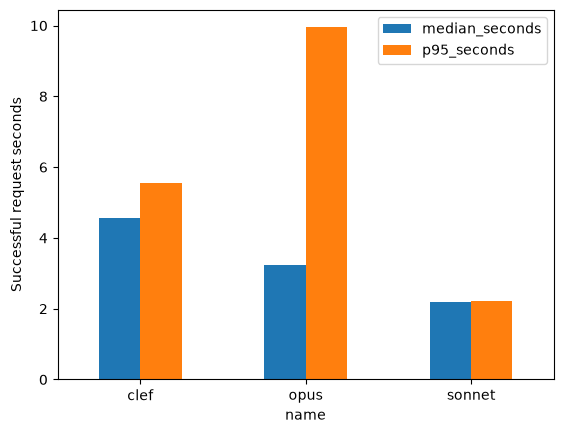

In [ ]:
measured["valid"] = measured["status"].eq("ok") & measured["score"].between(
    0, 1
)
valid = measured[measured["valid"]]
operations = measured.groupby("name").agg(
    attempted=("valid", "size"), valid=("valid", "sum")
)
operations["success_rate"] = operations["valid"] / operations["attempted"]
operations["median_seconds"] = valid.groupby("name")["latency_seconds"].median()
operations["p95_seconds"] = valid.groupby("name")["latency_seconds"].quantile(
    0.95
)
display(operations)
display(measured.groupby(["name", "status"]).size().to_frame("calls"))
operations[["median_seconds", "p95_seconds"]].plot.bar(
    rot=0, ylabel="Successful request seconds"
)
plt.show()

## Human alignment and score calibration

Labels are SummEval expert consistency ratings normalized from 1–5 to 0–1. The fixed pass threshold is 0.75. No calibrator is fitted to held-out labels. The curves below show how predicted ratings align with expert ratings, not the probability of an event. The sample may be skewed toward highly consistent summaries; inspect the label distribution and bin counts.

Rank correlation is descriptive and does not establish interchangeability. Multiple summaries from one article and repeated judgments are not independent observations; these tables do not make significance claims.

In [ ]:
paired = valid.pivot(
    index=["example_id", "article_id", "repeat", "true_label"],
    columns="name",
    values="score",
)
paired = paired.reindex(columns=list(metadata["models"]))
paired = paired.dropna().reset_index()
print(f"Common successful example/trial pairs: {len(paired)}")
if paired.empty:
    raise ValueError("No complete panels; inspect the failure table first.")
reports = {
    (model, repeat): AlignmentReport(
        predicted_scores=rows[model].tolist(),
        true_labels=rows["true_label"].tolist(),
        examples=rows.to_dict(orient="records"),
        threshold=THRESHOLD,
    )
    for repeat, rows in paired.groupby("repeat")
    for model in metadata["models"]
}
trial_summaries = [
    report.to_dataframe()["summary"].assign(model=model, trial=repeat + 1)
    for (model, repeat), report in reports.items()
]
display(pd.concat(trial_summaries, ignore_index=True))
model_report = CrossModelAlignmentReport(
    names=list(metadata["models"]),
    scores=[paired[model].tolist() for model in metadata["models"]],
    expected=paired["true_label"].tolist(),
)
display(pd.DataFrame(model_report.ground_truth_metrics()).T)
display(
    pd.DataFrame(
        model_report.spearman,
        index=model_report.names,
        columns=model_report.names,
    )
)
labels = measured.drop_duplicates("example_id")["true_label"]
display(labels.describe().to_frame("expert_consistency"))

Common successful example/trial pairs: 3


,metric,value,model,trial
0,MAE,0.042335,clef,1
1,Spearman correlation,1.000000,clef,1
2,Kendall's tau,1.000000,clef,1
3,Cohen's kappa at 0.75,1.000000,clef,1
4,Brier score,0.002611,clef,1
5,AUC,1.000000,clef,1
6,MAE,0.194444,opus,1
7,Spearman correlation,1.000000,opus,1
8,Kendall's tau,1.000000,opus,1
9,Cohen's kappa at 0.75,0.400000,opus,1


,mae,spearman,kendall
clef,0.042335,1.0,1.0
opus,0.194444,1.0,1.0
sonnet,0.194444,1.0,1.0


,clef,opus,sonnet
clef,1.0,1.0,1.0
opus,1.0,1.0,1.0
sonnet,1.0,1.0,1.0


,expert_consistency
count,3.000000
mean,0.777778
std,0.315495
min,0.416667
25%,0.666667
50%,0.916667
75%,0.958333
max,1.000000


clef


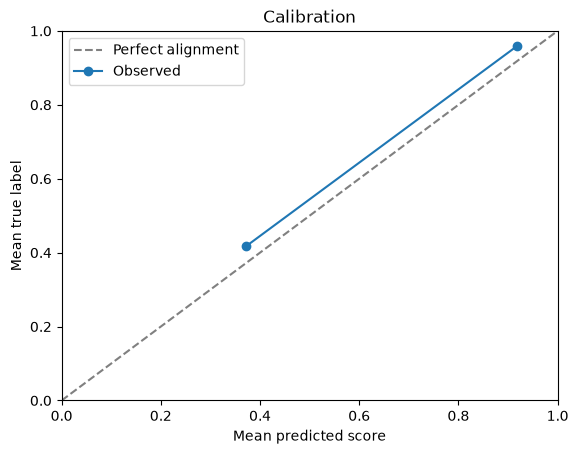

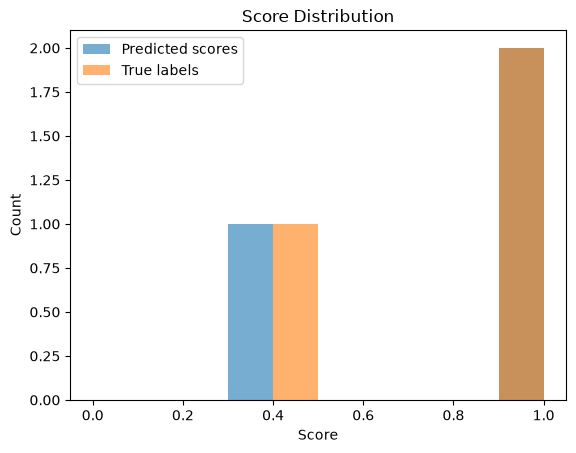

,bin,bin_lower,bin_upper,count,mean_predicted_score,mean_true_label
0,0,0.0,0.1,0,NaN,NaN
1,1,0.1,0.2,0,NaN,NaN
2,2,0.2,0.3,0,NaN,NaN
3,3,0.3,0.4,1,0.371204,0.416667
4,4,0.4,0.5,0,NaN,NaN
5,5,0.5,0.6,0,NaN,NaN
6,6,0.6,0.7,0,NaN,NaN
7,7,0.7,0.8,0,NaN,NaN
8,8,0.8,0.9,0,NaN,NaN
9,9,0.9,1.0,2,0.917563,0.958333


opus


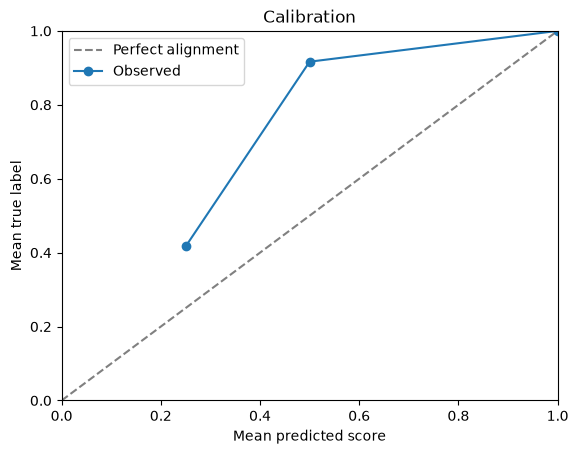

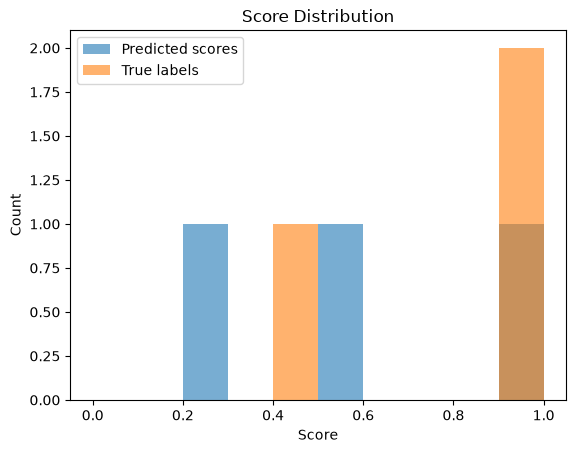

,bin,bin_lower,bin_upper,count,mean_predicted_score,mean_true_label
0,0,0.0,0.1,0,NaN,NaN
1,1,0.1,0.2,0,NaN,NaN
2,2,0.2,0.3,1,0.25,0.416667
3,3,0.3,0.4,0,NaN,NaN
4,4,0.4,0.5,0,NaN,NaN
5,5,0.5,0.6,1,0.50,0.916667
6,6,0.6,0.7,0,NaN,NaN
7,7,0.7,0.8,0,NaN,NaN
8,8,0.8,0.9,0,NaN,NaN
9,9,0.9,1.0,1,1.00,1.000000


sonnet


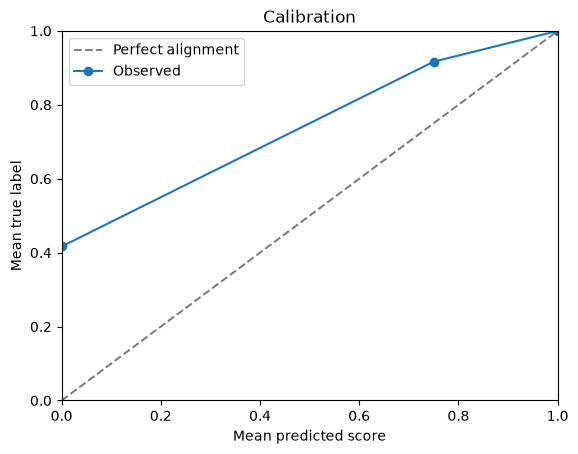

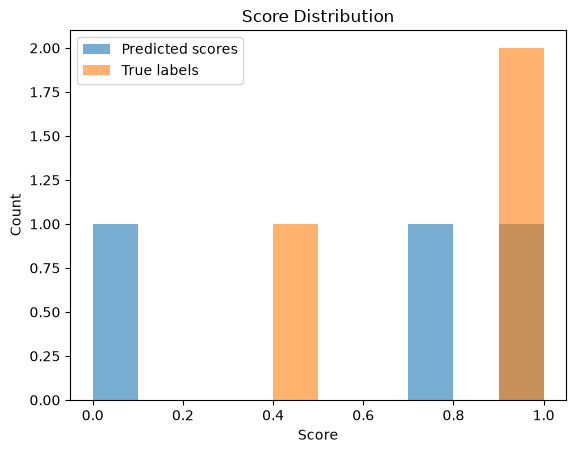

,bin,bin_lower,bin_upper,count,mean_predicted_score,mean_true_label
0,0,0.0,0.1,1,0.00,0.416667
1,1,0.1,0.2,0,NaN,NaN
2,2,0.2,0.3,0,NaN,NaN
3,3,0.3,0.4,0,NaN,NaN
4,4,0.4,0.5,0,NaN,NaN
5,5,0.5,0.6,0,NaN,NaN
6,6,0.6,0.7,0,NaN,NaN
7,7,0.7,0.8,1,0.75,0.916667
8,8,0.8,0.9,0,NaN,NaN
9,9,0.9,1.0,1,1.00,1.000000


In [ ]:
# Native plots for the first available trial; every trial is summarized above.
first_trial = int(paired["repeat"].min())
for model in metadata["models"]:
    print(model)
    figures = reports[(model, first_trial)].plot()
    plt.show()
    display(reports[(model, first_trial)].to_dataframe()["calibration"])

In [ ]:
for model in metadata["models"]:
    print(model, "largest absolute errors, first available trial")
    misses = reports[(model, first_trial)].to_dataframe()["worst_misses"]
    display(misses.head(5))

clef largest absolute errors, first available trial


,index,predicted_score,true_label,absolute_error,example_id,article_id,repeat,example_true_label,clef,opus,sonnet
0,2,0.924282,1.000000,0.075718,dm-test-e470f0a87d7513bf880412524332047020422c...,dm-test-e470f0a87d7513bf880412524332047020422c3f,0,1.000000,0.924282,1.00,1.00
1,0,0.371204,0.416667,0.045463,dm-test-2feca9acf532e33f1ab7442c442c8e19787d8d...,dm-test-2feca9acf532e33f1ab7442c442c8e19787d8d7b,0,0.416667,0.371204,0.25,0.00
2,1,0.910843,0.916667,0.005823,dm-test-632cfdb03aacd90a34a470f6a70b47eee62ec5...,dm-test-632cfdb03aacd90a34a470f6a70b47eee62ec5f0,0,0.916667,0.910843,0.50,0.75


opus largest absolute errors, first available trial


,index,predicted_score,true_label,absolute_error,example_id,article_id,repeat,example_true_label,clef,opus,sonnet
0,1,0.50,0.916667,0.416667,dm-test-632cfdb03aacd90a34a470f6a70b47eee62ec5...,dm-test-632cfdb03aacd90a34a470f6a70b47eee62ec5f0,0,0.916667,0.910843,0.50,0.75
1,0,0.25,0.416667,0.166667,dm-test-2feca9acf532e33f1ab7442c442c8e19787d8d...,dm-test-2feca9acf532e33f1ab7442c442c8e19787d8d7b,0,0.416667,0.371204,0.25,0.00
2,2,1.00,1.000000,0.000000,dm-test-e470f0a87d7513bf880412524332047020422c...,dm-test-e470f0a87d7513bf880412524332047020422c3f,0,1.000000,0.924282,1.00,1.00


sonnet largest absolute errors, first available trial


,index,predicted_score,true_label,absolute_error,example_id,article_id,repeat,example_true_label,clef,opus,sonnet
0,0,0.00,0.416667,0.416667,dm-test-2feca9acf532e33f1ab7442c442c8e19787d8d...,dm-test-2feca9acf532e33f1ab7442c442c8e19787d8d7b,0,0.416667,0.371204,0.25,0.00
1,1,0.75,0.916667,0.166667,dm-test-632cfdb03aacd90a34a470f6a70b47eee62ec5...,dm-test-632cfdb03aacd90a34a470f6a70b47eee62ec5f0,0,0.916667,0.910843,0.50,0.75
2,2,1.00,1.000000,0.000000,dm-test-e470f0a87d7513bf880412524332047020422c...,dm-test-e470f0a87d7513bf880412524332047020422c3f,0,1.000000,0.924282,1.00,1.00


## Jury and consumption

The median jury replays recorded scores using TruLens `Jury`; it makes no additional model calls. Alignment uses complete panels only, with missing pairs excluded as counted above. Repeated-call metrics use complete three-trial cohorts shared by every model. Native `reliability.flip_rate` measures the fraction of votes disagreeing with the majority at 0.75, not the fraction of examples that flipped at least once. There is no measured live-jury latency.

Cortex consumption is shown in input/output tokens. Dollar cost is unknown; direct Anthropic rates do not apply. Clef has no provider API charge, but local hardware/electricity costs are not measured. This run does not establish a total-cost comparison.

In [ ]:
class RecordedJudge:
    """Replay measured scores so native Jury analysis needs no new calls."""

    def __init__(self, name, score):
        self.model_engine = name
        self.value = score

    def score(self, **kwargs):
        return self.value


repeat_results = []
for model in metadata["models"]:
    for example_id, rows in paired.groupby("example_id"):
        if len(rows) != metadata["repeats"]:
            continue
        repeated = Jury(
            [
                RecordedJudge(model, score)
                for score in rows.sort_values("repeat")[model]
            ],
            method="score",
            max_workers=1,
            threshold=THRESHOLD,
        )
        _, reliability = repeated()
        repeat_results.append({
            "model": model,
            "example_id": example_id,
            **reliability,
        })
reliability = pd.DataFrame(repeat_results)
if not reliability.empty:
    display(reliability.groupby("model").size().to_frame("complete_cohorts"))
    display(
        reliability.groupby("model")[
            [
                "reliability.score_std",
                "reliability.flip_rate",
                "reliability.outcome_entropy",
            ]
        ].mean()
    )
else:
    print("No complete repeated-trial cohorts.")

jury_scores = []
for row in paired.to_dict(orient="records"):
    jury = Jury(
        [RecordedJudge(model, row[model]) for model in metadata["models"]],
        method="score",
        aggregation="median",
        threshold=THRESHOLD,
    )
    score, _ = jury()
    jury_scores.append(score)
jury_report = AlignmentReport(
    jury_scores, paired["true_label"].tolist(), threshold=THRESHOLD
)
display(jury_report.to_dataframe()["summary"])
usage = pd.DataFrame([
    {"model": row["name"], **row["usage"]}
    for row in measured.to_dict(orient="records")
    if isinstance(row.get("usage"), dict)
])
if not usage.empty:
    display(usage.groupby("model").sum(numeric_only=True))
    display(usage.groupby("model").size().to_frame("calls_with_usage"))
print(metadata["cost_note"])

,complete_cohorts
model,
clef,3
opus,3
sonnet,3


,reliability.score_std,reliability.flip_rate,reliability.outcome_entropy
model,,,
clef,0.0,0.0,0.0
opus,0.0,0.0,0.0
sonnet,0.0,0.0,0.0


,metric,value
0,MAE,0.111111
1,Spearman correlation,1.000000
2,Kendall's tau,1.000000
3,Cohen's kappa at 0.75,1.000000
4,Brier score,0.018519
5,AUC,1.000000


,input_tokens,output_tokens,cache_read_input_tokens,cache_creation_input_tokens
model,,,,
clef,2404,0,0,0
opus,3112,324,0,0
sonnet,3112,361,0,0


,calls_with_usage
model,
clef,3
opus,3
sonnet,3


Cortex USD unknown. Local API charge excludes hardware/electricity.


## Reproduce

Install the dependencies listed in [README.md](README.md), pull `clef` with Ollama 0.35.1 or newer, and configure `SNOWFLAKE_CONNECTION_NAME`. Set `RUN_LIVE=True` and execute the live cells. They use native `Jury.repeated` and save `live_results.json`; leave live mode off to reproduce the included analysis without new charges.

The included snapshot comes from the earlier interleaved execution of the same frozen dataset, rubric, model settings, and three-trial design. Its Cortex scoring used a strict terminal-JSON parser; the simplified live example uses TruLens `generate_score` parsing. These are documented as different parser configurations, not asserted to be byte-identical reruns. Do not mix outputs from the two runs.

No calibrator was fitted on the held-out labels. Public benchmarks may overlap model training. Summaries from one article and repeated calls are dependent observations. Calibration curves describe ordinal score agreement, not event probabilities; results apply only to this task and deployment.